<a href="https://colab.research.google.com/github/Muawana038/simulasi-ecg-colab/blob/main/simulasi_ecg_premium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

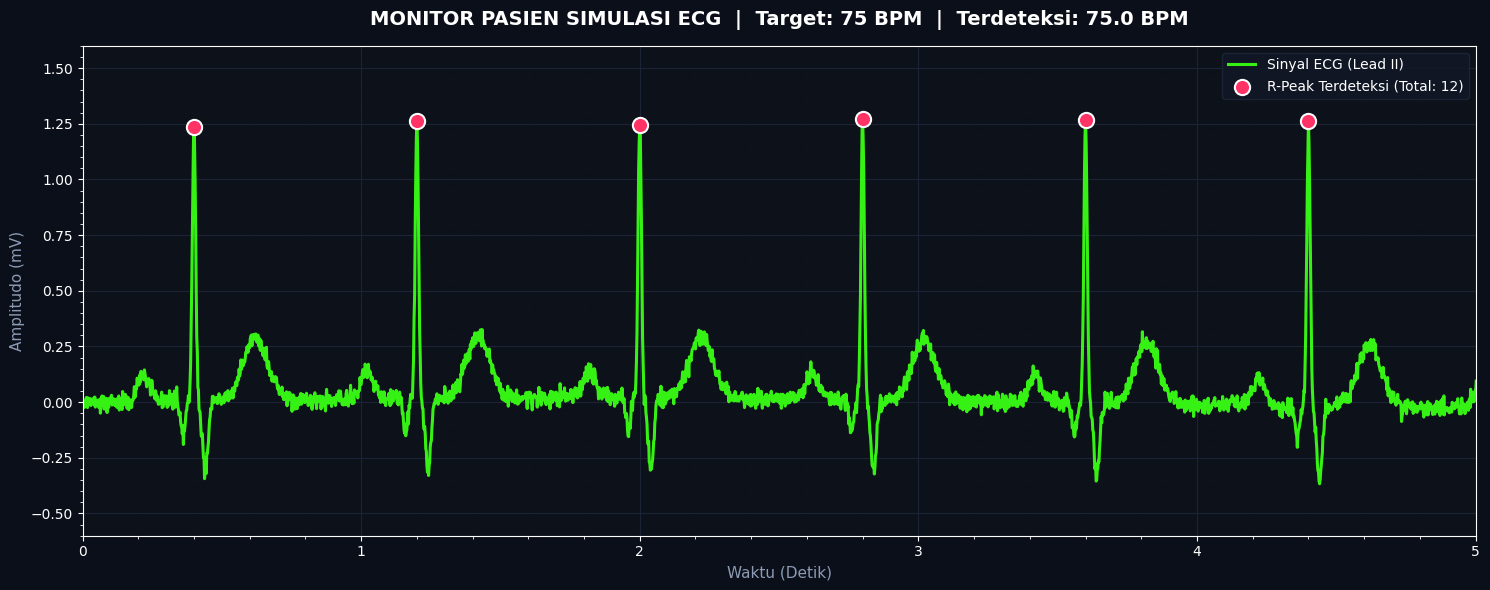

🔊 MEMUTAR SUARA MONITOR PASIEN (SINKRON DENGAN GRAFIK DI ATAS):


In [8]:
# simulasi_ecg_premium.py
# Premium ECG Simulator dengan Sinyal Realistis, Visualisasi Monitor ICU, dan Efek Suara Beep Synced.
# Didesain khusus untuk dijalankan di Google Colab.

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from IPython.display import Audio, display

def generate_realistic_ecg(duration=10, fs=500, bpm=75):
    """
    Menghasilkan sinyal ECG sintetis dengan akurasi morfologi tinggi menggunakan model multi-Gaussian
    untuk mensimulasikan gelombang P, Q, R, S, dan T secara realistis.
    """
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    ecg = np.zeros_like(t)

    # Menghitung interval antar detak (R-to-R interval dalam detik)
    rr_interval = 60.0 / bpm

    # Menentukan pusat-pusat detak jantung sepanjang durasi
    num_beats = int(duration / rr_interval) + 1
    beat_centers = [0.4 + i * rr_interval for i in range(num_beats)]

    # Parameter gelombang PQRST (amplitudo, offset waktu relatif ke puncak R, lebar gelombang)
    pqrst_parameters = [
        # P wave: gelombang kecil sebelum QRS
        {'amp': 0.12, 'offset': -0.18, 'width': 0.022},
        # Q wave: defleksi negatif tajam sebelum R
        {'amp': -0.15, 'offset': -0.04, 'width': 0.008},
        # R wave: puncak positif sangat tinggi dan tajam
        {'amp': 1.25, 'offset': 0.00, 'width': 0.006},
        # S wave: defleksi negatif tajam setelah R
        {'amp': -0.32, 'offset': 0.04, 'width': 0.010},
        # T wave: gelombang pemulihan setelah QRS
        {'amp': 0.28, 'offset': 0.22, 'width': 0.042}
    ]

    # Gabungkan gelombang untuk setiap detak jantung
    for center in beat_centers:
        for wave in pqrst_parameters:
            wave_center = center + wave['offset']
            # Persamaan Gaussian: amp * exp( - (t - center)^2 / (2 * width^2) )
            ecg += wave['amp'] * np.exp(-((t - wave_center) ** 2) / (2 * (wave['width'] ** 2)))

    return t, ecg

def add_realistic_noise(ecg_signal, fs, noise_level=0.01, drift_level=0.03):
    """
    Menambahkan noise acak (high frequency) dan baseline wander (low frequency drift akibat pernapasan).
    """
    # 1. White Noise (derau frekuensi tinggi)
    noise = np.random.normal(0, noise_level, len(ecg_signal))

    # 2. Baseline Wander (derau frekuensi rendah / efek gerakan dada saat bernapas @ ~0.15 Hz)
    t_arr = np.linspace(0, len(ecg_signal)/fs, len(ecg_signal), endpoint=False)
    wander = drift_level * np.sin(2 * np.pi * 0.15 * t_arr)

    return ecg_signal + noise + wander

def analyze_ecg_peaks(t, ecg_signal, fs):
    """
    Mendeteksi puncak R-wave dan menghitung nilai BPM berdasarkan analisis interval puncak.
    """
    # Mengatur jarak minimal antar puncak (distance) agar tidak mendeteksi puncak ganda pada T-wave
    peaks, _ = find_peaks(ecg_signal, height=0.4, distance=int(fs * 0.4))

    # Menghitung BPM yang lebih akurat dari selisih waktu antar puncak (R-to-R interval)
    if len(peaks) > 1:
        rr_intervals = np.diff(t[peaks])
        calculated_bpm = 60.0 / np.mean(rr_intervals)
    else:
        calculated_bpm = 0.0

    return peaks, calculated_bpm

def generate_heartbeat_audio(peaks, t, duration, audio_fs=8000):
    """
    Menghasilkan sinyal audio (Waveform) dengan suara 'beep' (1000 Hz) sinkron pada setiap puncak R.
    """
    audio_len = int(duration * audio_fs)
    audio_signal = np.zeros(audio_len)

    # Parameter suara 'beep'
    beep_freq = 1000  # Frekuensi 1000 Hz (suara alarm monitor standar)
    beep_duration = 0.08  # Durasi bunyi beep (80 milidetik)
    beep_samples = int(beep_duration * audio_fs)

    # Membuat satu buah template bunyi beep dengan efek fade-out agar tidak ada suara klik statis
    t_beep = np.linspace(0, beep_duration, beep_samples, endpoint=False)
    beep_template = np.sin(2 * np.pi * beep_freq * t_beep) * 0.4
    fade_window = np.cos(np.linspace(0, np.pi/2, beep_samples)) # Efek fade out melengkung
    beep_template *= fade_window

    # Tempatkan template beep pada posisi puncak-puncak R yang terdeteksi
    for peak_idx in peaks:
        peak_time = t[peak_idx]
        start_idx = int(peak_time * audio_fs)
        end_idx = start_idx + beep_samples

        if end_idx < audio_len:
            audio_signal[start_idx:end_idx] += beep_template

    return audio_signal

# --- PARAMETER UTAMA (Silakan Ubah Nilai Di Bawah Ini) ---
target_bpm = 75         # Frekuensi jantung target (BPM)
duration_seconds = 10    # Durasi simulasi (detik)
level_noise = 0.02     # Tingkat noise frekuensi tinggi (sangat kecil untuk hasil super bersih)
level_drift = 0.02      # Tingkat pergeseran baseline (pernapasan)
sampling_rate = 500     # Sampling rate tinggi (500 Hz) untuk grafik super mulus
# ---------------------------------------------------------

# 1. Generate Sinyal Realistis (Pristine)
t, ecg_clean = generate_realistic_ecg(duration=duration_seconds, fs=sampling_rate, bpm=target_bpm)

# 2. Tambahkan Sedikit Noise & Baseline Wander agar Terlihat Alami tapi Tetap Bersih
ecg_noisy = add_realistic_noise(ecg_clean, fs=sampling_rate, noise_level=level_noise, drift_level=level_drift)

# 3. Analisis Sinyal (Cari Puncak R & Hitung Real BPM)
peaks, calculated_bpm = analyze_ecg_peaks(t, ecg_noisy, fs=sampling_rate)

# 4. Buat Efek Suara Monitor Beep Sinkron
audio_data = generate_heartbeat_audio(peaks, t, duration=duration_seconds)

# 5. Visualisasi Grafik Premium Bergaya Monitor Pasien ICU (Clinical Style)
plt.style.use('dark_background')  # Menggunakan mode gelap bawaan matplotlib
fig, ax = plt.subplots(figsize=(15, 6), facecolor='#0b0f19')
ax.set_facecolor('#0d111a')

# Plot garis grid dengan warna cyan lembut transparan layaknya oscilloscope monitor medis
ax.grid(True, which='both', color='#1a2436', linestyle='-', linewidth=0.8)
ax.minorticks_on()
ax.grid(True, which='minor', color='#111822', linestyle=':', linewidth=0.5)

# Plot Sinyal ECG dengan warna Hijau Neon yang Tajam dan Mulus
ax.plot(t, ecg_noisy, color='#39ff14', linewidth=2.2, label='Sinyal ECG (Lead II)', alpha=0.95)

# Plot titik deteksi puncak (R-Peak) dengan warna Merah/Oranye Menyala
ax.scatter(t[peaks], ecg_noisy[peaks], color='#ff3366', s=120, zorder=5,
           edgecolors='#ffffff', linewidths=1.5, label=f'R-Peak Terdeteksi (Total: {len(peaks)})')

# Tambahkan Judul dan Keterangan Parameter dengan Font yang Bersih
ax.set_title(f"MONITOR PASIEN SIMULASI ECG  |  Target: {target_bpm} BPM  |  Terdeteksi: {calculated_bpm:.1f} BPM",
             color='#ffffff', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Waktu (Detik)", color='#8b9bb4', fontsize=11)
ax.set_ylabel("Amplitudo (mV)", color='#8b9bb4', fontsize=11)
ax.legend(loc='upper right', facecolor='#111827', edgecolor='#1e293b', labelcolor='#ffffff')

# Batasi visualisasi untuk menampilkan 5 detik pertama agar gelombang terlihat detail dan estetik
ax.set_xlim(0, 5)
ax.set_ylim(-0.6, 1.6)

plt.tight_layout()
plt.show()

# 6. Jalankan Suara Monitor Detak Jantung (Beep) di Google Colab
print("🔊 MEMUTAR SUARA MONITOR PASIEN (SINKRON DENGAN GRAFIK DI ATAS):")
display(Audio(audio_data, rate=8000, autoplay=False))